# 05 — 1D CNN

Standalone notebook. Run `00_Preprocessing.ipynb` first. Each feature
is treated as one timestep with 1 channel (standard tabular→sequence
framing for CNN/RNN architectures on flow-based IDS data).

In [1]:
import os, time
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from utils import PROCESSED_DIR, RESULTS_DIR, MODELS_DIR, PLOTS_DIR, evaluate, save_results

SEED = 42
tf.random.set_seed(SEED)
MODEL_NAME = "1D CNN"
DL_EPOCHS = 20
DL_BATCH_SIZE = 256


## Load Preprocessed Data

In [2]:
X_train_res = np.load(os.path.join(PROCESSED_DIR, "X_train_res.npy"))
y_train_res = np.load(os.path.join(PROCESSED_DIR, "y_train_res.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
class_names = joblib.load(os.path.join(PROCESSED_DIR, "class_names.joblib"))
n_classes = joblib.load(os.path.join(PROCESSED_DIR, "n_classes.joblib"))

X_train_res_seq = X_train_res.reshape((X_train_res.shape[0], X_train_res.shape[1], 1))
X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(f"Train: {X_train_res_seq.shape}, Test: {X_test_seq.shape}, classes: {n_classes}")


Train: (911664, 78, 1), Test: (53582, 78, 1), classes: 15


## Build & Train

In [3]:
def build_cnn1d(n_features, n_classes):
    model = models.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.Conv1D(64, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


model = build_cnn1d(X_train_res.shape[1], n_classes)
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

t0 = time.time()
history = model.fit(
    X_train_res_seq, y_train_res, validation_split=0.1,
    epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
    callbacks=[early_stop], verbose=2,
)
train_time = time.time() - t0
print(f"Train time: {train_time:.2f}s")


Epoch 1/20
3206/3206 - 70s - 22ms/step - accuracy: 0.7678 - loss: 0.7190 - val_accuracy: 0.3790 - val_loss: 6.2284
Epoch 2/20
3206/3206 - 51s - 16ms/step - accuracy: 0.9075 - loss: 0.2921 - val_accuracy: 0.3924 - val_loss: 5.7795
Epoch 3/20
3206/3206 - 47s - 15ms/step - accuracy: 0.9286 - loss: 0.2235 - val_accuracy: 0.3894 - val_loss: 5.3677
Epoch 4/20
3206/3206 - 56s - 17ms/step - accuracy: 0.9406 - loss: 0.1846 - val_accuracy: 0.4094 - val_loss: 5.0461
Epoch 5/20
3206/3206 - 81s - 25ms/step - accuracy: 0.9459 - loss: 0.1676 - val_accuracy: 0.4051 - val_loss: 5.1456
Epoch 6/20
3206/3206 - 48s - 15ms/step - accuracy: 0.9505 - loss: 0.1544 - val_accuracy: 0.4086 - val_loss: 5.3874
Epoch 7/20
3206/3206 - 48s - 15ms/step - accuracy: 0.9532 - loss: 0.1457 - val_accuracy: 0.4079 - val_loss: 5.2314
Train time: 401.04s


## Predict & Evaluate

In [4]:
t0 = time.time()
y_proba = model.predict(X_test_seq, verbose=0)
infer_time = time.time() - t0
y_pred = np.argmax(y_proba, axis=1)

row = evaluate(MODEL_NAME, y_test, y_pred, y_proba, train_time, infer_time, n_classes)
for k, v in row.items():
    if k not in ("Confusion Matrix",):
        print(f"{k}: {v}")


Model: 1D CNN
Accuracy: 0.9172296666791087
Precision: 0.39268716566330936
Recall: 0.7682940091518923
F1-Score: 0.45973203045518496
ROC-AUC: nan
MCC: 0.7919705783698635
Cohen's Kappa: 0.7789480897462561
Train Time (s): 401.03761744499207
Prediction Time (s): 5.156002521514893


## Training Curves

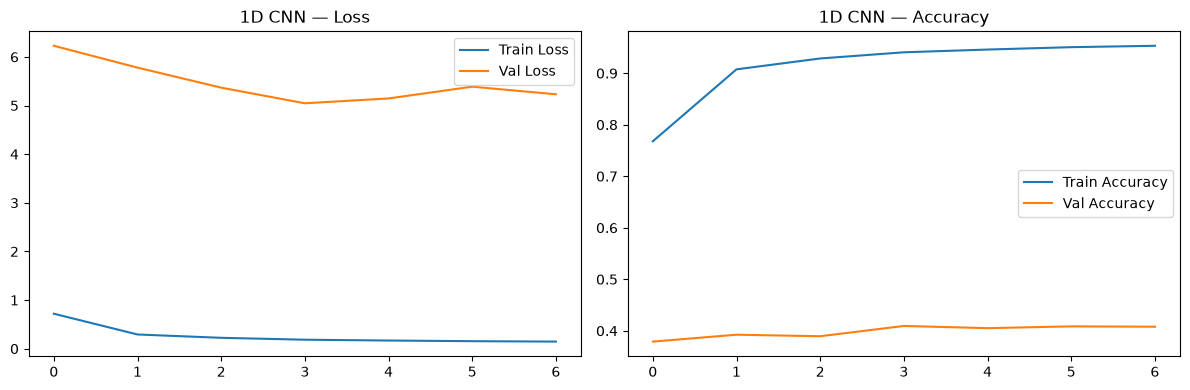

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title(f"{MODEL_NAME} — Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title(f"{MODEL_NAME} — Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "CNN1D_training_curves.png"), dpi=150)
plt.show()


## Confusion Matrix Plot

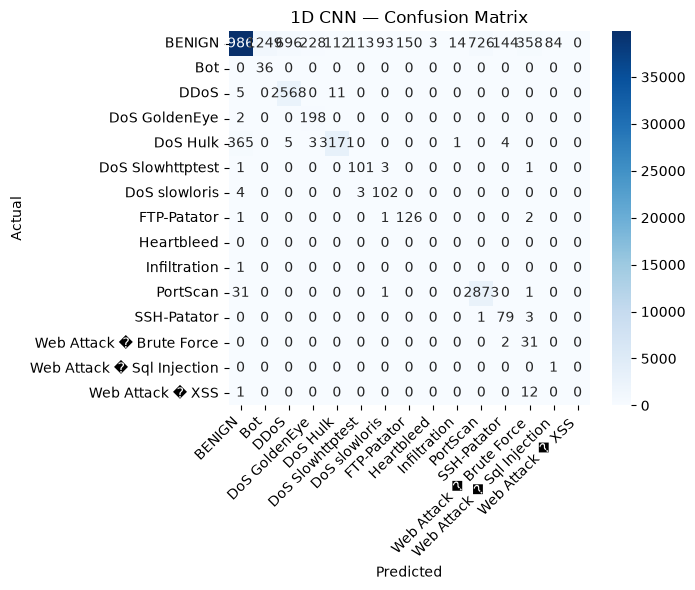

In [6]:
cm = np.array(row["Confusion Matrix"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{MODEL_NAME} — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "CNN1D_confusion_matrix.png"), dpi=150)
plt.show()


## Save Results & Model

In [7]:
save_results(MODEL_NAME, row, history=history.history)
model.save(os.path.join(MODELS_DIR, "CNN1D.keras"))
print("Saved model and results for", MODEL_NAME)


Saved results to results\1D_CNN_results.json
Saved model and results for 1D CNN
